# Kritieke-padplanning van de lancering van een autoverzekeringsproduct

## Managementsamenvatting

Het lanceren van een autoverzekering voor particulieren is een multidisciplinair programma: actuarissen bepalen de premie voor het risico, compliance dient de tarieven in bij de staat en wacht op goedkeuring, IT configureert het polisadministratiesysteem en distributie leidt agenten op. Deze taken hebben harde volgorderelaties, dus de lanceringsdatum wordt bepaald door de langste afhankelijke keten door het plan -- het **kritieke pad**.

Dit notebook bouwt een Activity-on-Node-projectnetwerk van elf lanceringstaken en berekent een volledig **Critical Path Method (CPM)**-schema met **PROC OPTMODEL**. De voorwaartse en achterwaartse berekeningen van CPM zijn lineaire programma's over de volgordegraaf: de voorwaartse berekening (langste pad vanaf de start) geeft de vroegste start en het vroegste einde van elke taak, en een achterwaartse langste-padberekening geeft de laatste start en het laatste einde en de **totale speling** (schemaspeling). De onderstaande resultaten worden volledig geproduceerd door de code in dit notebook -- elk getal in het verhaal wordt teruggelezen uit de uitgevoerde output.

**Wat het schema laat zien.** Op een werkkalender van vijf dagen verankerd op 01JUN2026 beslaat het programma **97 werkdagen** en eindigt het op **13OCT2026**. Negen van de elf taken liggen op het kritieke pad (Aftrap -> Marktonderzoek -> Schadedata -> Tarifering -> Systeemontwerp -> Systeembouw -> UAT -> Agenttraining -> Lancering) en hebben nul speling. Alleen de regelgevingstak -- **Tariefindiening** en **Goedkeuring** -- heeft speling: elk kan tot **30 werkdagen** uitlopen zonder de lancering te verschuiven, omdat de parallelle systeembouwtak de langere is van de twee samenkomende paden.

## Hoe dit is opgebouwd

CPM is klassiek een SAS/OR-procedure, maar de kernberekening bestaat uit een paar langste-padproblemen op de volgordegraaf, die PROC OPTMODEL rechtstreeks uitdrukt als kleine lineaire programma's:

- **Voorwaartse berekening (vroegste tijden).** Minimaliseer de vroegste-startvariabelen onder de voorwaarde `ES[successor] >= ES[predecessor] + duration + lag` voor elke volgordeboog. In het optimum is elke `ES` gelijk aan het langste pad vanaf de projectstart, d.w.z. het vroegste moment waarop de taak kan beginnen.
- **Achterwaartse berekening (laatste tijden / speling).** Bereken voor elke taak het langste resterende pad tot het projecteinde (`TAIL`). De laatste start is dan `makespan - TAIL`, en de **totale speling** is `late start - early start`. Taken met nul speling zijn kritiek.

Het netwerk, de doorlooptijden, de volgordevertragingen en de resourcevraag per taak worden allemaal inline gegenereerd; er zijn geen externe invoerbestanden. Werkdag-kalenderdata worden afgeleid met `INTNX('weekday', ...)` zodat weekenden worden overgeslagen.

## Data

| Dataset | Rijen | Sleutelvariabelen | Beschrijving |
|---------|------|---------------|-------------|
| `acts`  | 11 | `id`, `activity`, `dur`, `actuary`, `developer` | Activiteitenoverzicht: elke lanceringstaak, de duur in werkdagen en de dagelijkse bezetting aan actuarissen / ontwikkelaars die nodig is |
| `arcs`  | 12 | `pred`, `succ`, `lag` | Volgordebogen van het Activity-on-Node-netwerk; `lag` is een finish-to-start-vertraging in werkdagen (de wettelijke wachtperiode na goedkeuring) |

Numerieke activiteits-ID's vormen de sleutel van het netwerk zodat de volgordegraaf netjes in OPTMODEL's tuple-set wordt ingelezen; de leesbare `activity`-namen worden achteraf weer aan het schema toegevoegd.

In [1]:
GEGEVENS acts;
   LENGTE activity $16;
   INVOER id activity $ dur actuary developer;
   DATALINES;
1 Aftrap          3 1 0
2 Marktonderzoek  8 2 0
3 Schadedata     10 3 0
4 Tarifering      9 3 1
5 Tariefindiening 4 1 0
6 Goedkeuring     6 1 0
7 Systeemontwerp 12 1 2
8 Systeembouw    18 0 3
9 UAT            15 0 2
10 Agenttraining 20 1 1
11 Lancering      2 1 1
;
UITVOEREN;

GEGEVENS arcs;
   INVOER pred succ lag;
   DATALINES;
1 2 0
2 3 0
3 4 0
4 5 0
4 7 0
5 6 0
6 10 5
7 8 0
8 9 0
9 10 0
9 11 0
10 11 0
;
UITVOEREN;

/* alleen-numerieke weergave van doorlooptijden voor OPTMODEL */
GEGEVENS acts_n; INSTELLEN acts; BEWAREN id dur; UITVOEREN;


NOTE: DATA acts

NOTE: Processing inline DATALINES (11 lines)

NOTE: Read 11 rows from DATALINES.
NOTE: Wrote acts (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA arcs

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote arcs (12 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA acts_n


NOTE: Read 11 rows from acts.
NOTE: Wrote acts_n (11 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Voorwaartse berekening -- vroegste start en einde

De voorwaartse berekening is een langste-pad-LP. De voorwaarde `ES[j] >= ES[i] + dur[i] + lag[i,j]` voor elke boog dwingt elke taak om niet eerder te starten dan al haar voorgangers klaar zijn (plus een eventuele wettelijke vertraging); het minimaliseren van de vroegste-startvariabelen brengt elke taak naar haar langste voorgangerspad. We schrijven de opgeloste `ES`-waarden rechtstreeks vanuit de OPTMODEL-variabele weg naar `fwd`.

In [2]:
PROCEDURE optmodel;
   INSTELLEN NODES; num dur{NODES};
   READ GEGEVENS acts_n INTO NODES=[id] dur=dur;

   INSTELLEN <num,num> ARCS; num lag{ARCS};
   READ GEGEVENS arcs INTO ARCS=[pred succ] lag=lag;

   VARIABELE ES{NODES} >= 0;
   con prec{<i,j> in ARCS}:
       ES[j] >= ES[i] + dur[i] + lag[i,j];
   MIN total_es = sum{k in NODES} ES[k];
   solve;

   CREATE GEGEVENS fwd FROM [id]=NODES es=ES;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_ES
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         12

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_ES
  Solution Status               Optimal
  Objective Value               401.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Achterwaartse berekening -- laatste tijden en totale speling

`TAIL[a]` is het langste pad van taak `a` tot het projecteinde, dus het moet de eigen duur van de taak dekken en, voor elke opvolger, de vertraging plus de tail van die opvolger: `TAIL[i] >= dur[i] + lag[i,j] + TAIL[j]`. Het minimaliseren van de tails levert de krapst mogelijke waarden op. De **makespan** van het project is het grootste vroegste einde; de **laatste start** van elke taak is `makespan - TAIL`, en de **totale speling** is `late start - early start`. Een speling van nul markeert het kritieke pad.

In [3]:
PROCEDURE optmodel;
   INSTELLEN NODES; num dur{NODES};
   READ GEGEVENS acts_n INTO NODES=[id] dur=dur;

   INSTELLEN <num,num> ARCS; num lag{ARCS};
   READ GEGEVENS arcs INTO ARCS=[pred succ] lag=lag;

   VARIABELE TAIL{NODES} >= 0;
   con BASE{a in NODES}: TAIL[a] >= dur[a];
   con back{<i,j> in ARCS}:
       TAIL[i] >= dur[i] + lag[i,j] + TAIL[j];
   MIN total_tail = sum{k in NODES} TAIL[k];
   solve;

   CREATE GEGEVENS bwd FROM [id]=NODES tail=TAIL;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_TAIL
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         23

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_TAIL
  Solution Status               Optimal
  Objective Value               606.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Het schema en de kalender samenstellen

We voegen de vroegste starts en tails weer samen met het activiteitenoverzicht, leiden de laatste start / het laatste einde en de totale speling af, en zetten de werkdag-offsets om naar kalenderdata met `INTNX('weekday', ...)` zodat de data op werkdagen vallen. Een taak wordt als **kritiek** gemarkeerd wanneer haar totale speling nul is.

In [4]:
%LET anchor = '01jun2026'd;

GEGEVENS sched0;
   SAMENVOEGEN acts fwd bwd; VOLGENS id;
   ef = es + dur;            /* vroeg einde */
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=sched0 NOPRINT;
   UITVOER out=mk(VERWIJDEREN=_type_ _freq_) MAX(ef)=makespan;
UITVOEREN;

GEGEVENS sched;
   ALS _n_=1 DAN INSTELLEN mk;
   INSTELLEN sched0;
   BEHOUDEN mspan;
   ALS _n_=1 DAN mspan = makespan;
   ls = mspan - tail;        /* late start  */
   lf = ls + dur;            /* laat einde   */
   tfloat = ls - es;         /* totale speling */
   e_start  = intnx('weekday', &anchor, es,   'b');
   e_finish = intnx('weekday', &anchor, ef-1, 'b');
   l_start  = intnx('weekday', &anchor, ls,   'b');
   l_finish = intnx('weekday', &anchor, lf-1, 'b');
   critical = (round(tfloat,1e-6)=0);
   LENGTE cclass $10;
   ALS critical DAN cclass='Kritiek';
   ANDERS cclass='Speling';
   OPMAAK e_start e_finish l_start l_finish date9.;
UITVOEREN;

PROCEDURE SORTEREN GEGEVENS=sched out=sched_es; VOLGENS es id; UITVOEREN;


NOTE: DATA sched0

NOTE: Stream 1 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 11 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote sched0 (11 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mk has 1 observations and 1 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA sched


NOTE: Read 11 rows from sched0.
NOTE: Wrote sched (11 rows, 19 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from sched.
NOTE: Wrote sched_es (11 rows, 19 columns).
NOTE: PROC SORT statement used.


## Het CPM-schema

Vroegste/laatste start en einde zijn in werkdagen vanaf het ankerpunt 01JUN2026 (dag 0). Taken in de klasse **Kritiek** hebben nul totale speling.

In [5]:
TITEL 'CPM-planning -- werkdagtijden en totale speling';
PROCEDURE AFDRUKKEN GEGEVENS=sched_es noobs label;
   VARIABELE activity dur es ef ls lf tfloat cclass;
   label activity='Activiteit' dur='Duur(wd)' es='ES' ef='EF'
         ls='LS' lf='LF' tfloat='Totale speling' cclass='Klasse';
UITVOEREN;

                                    CPM-planning -- werkdagtijden en totale speling                                     


     Activiteit  Duur(wd)  ES  EF  LS  LF  Totale speling   Klasse
---------------  --------  --  --  --  --  --------------  -------
Aftrap                  3   0   3   0   3               0  Kritiek
Marktonderzoek          8   3  11   3  11               0  Kritiek
Schadedata             10  11  21  11  21               0  Kritiek
Tarifering              9  21  30  21  30               0  Kritiek
Tariefindiening         4  30  34  60  64              30  Speling
Systeemontwerp         12  30  42  30  42               0  Kritiek
Goedkeuring             6  34  40  64  70              30  Speling
Systeembouw            18  42  60  42  60               0  Kritiek
UAT                    15  60  75  60  75               0  Kritiek
Agenttraining          20  75  95  75  95               0  Kritiek
Lancering               2  95  97  95  97               0  Kritiek




NOTE: Option TITLE changed to CPM-planning -- werkdagtijden en totale speling.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 11 observations printed, 8 variables


De vroegste-startkolom volgt de afhankelijke keten: Aftrap begint op dag 0, en elke stroomafwaartse taak start zodra haar voorgangers klaar zijn. Het project wordt voltooid bij het grootste vroegste einde.

## Het kritieke pad

Alleen de taken met nul speling weergeven, met hun kalenderdata, geeft de keten die de lanceringsdatum bepaalt. Elke vertraging op deze taken verschuift de lancering dag voor dag.

In [6]:
TITEL 'Kritiek pad (totale speling = 0) met kalenderdata';
PROCEDURE AFDRUKKEN GEGEVENS=sched_es noobs label;
   WAAR critical=1;
   VARIABELE activity dur e_start e_finish;
   label activity='Activiteit' dur='Duur(wd)'
         e_start='Vroege start' e_finish='Vroeg einde';
UITVOEREN;

GEGEVENS mkrep;
   INSTELLEN mk;
   anchor = &anchor;
   FINISH = intnx('weekday', &anchor, makespan-1, 'b');
   OPMAAK anchor FINISH date9.;
UITVOEREN;
TITEL 'Projectduur';
PROCEDURE AFDRUKKEN GEGEVENS=mkrep noobs label;
   VARIABELE anchor makespan FINISH;
   label anchor='Anker (dag 0)'
         makespan='Doorlooptijd (werkdagen)'
         FINISH='Verwachte einddatum';
UITVOEREN;

                                   Kritiek pad (totale speling = 0) met kalenderdata                                    


    Activiteit  Duur(wd)  Vroege start  Vroeg einde
--------------  --------  ------------  -----------
Aftrap                 3     01JUN2026    03JUN2026
Marktonderzoek         8     04JUN2026    15JUN2026
Schadedata            10     16JUN2026    29JUN2026
Tarifering             9     30JUN2026    10JUL2026
Systeemontwerp        12     13JUL2026    28JUL2026
Systeembouw           18     29JUL2026    21AUG2026
UAT                   15     24AUG2026    11SEP2026
Agenttraining         20     14SEP2026    09OCT2026
Lancering              2     12OCT2026    13OCT2026

                                                      Projectduur                                                       


Anker (dag 0)  Doorlooptijd (werkdagen)  Verwachte einddatum
-------------  ------------------------  -------------------
    01JUN2026                        97            13OCT202


NOTE: Option TITLE changed to Kritiek pad (totale speling = 0) met kalenderdata.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 9 observations printed, 4 variables
NOTE: DATA mkrep


NOTE: Read 1 rows from mk.
NOTE: Wrote mkrep (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Projectduur.
NOTE: PROC PRINT data=mkrep

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## Waar de speling zit

De niet-kritieke taken vormen de regelgevingstak. Hun laatste start / einde laten zien hoever elke taak kan opschuiven voordat ze de lancering zou gaan opschuiven. De vrije speling is hier gelijk aan de totale speling omdat geen enkele andere taak van deze taken afhangt totdat ze weer samenkomen bij Agenttraining.

In [7]:
TITEL 'Niet-kritieke activiteiten en hun planningsspeling';
PROCEDURE AFDRUKKEN GEGEVENS=sched_es noobs label;
   WAAR critical=0;
   VARIABELE activity dur e_start e_finish l_start l_finish tfloat;
   label activity='Activiteit' dur='Duur(wd)'
         e_start='Vroege start' e_finish='Vroeg einde'
         l_start='Late start' l_finish='Laat einde'
         tfloat='Totale speling';
UITVOEREN;

                                   Niet-kritieke activiteiten en hun planningsspeling                                   


     Activiteit  Duur(wd)  Vroege start  Vroeg einde  Late start  Laat einde  Totale speling
---------------  --------  ------------  -----------  ----------  ----------  --------------
Tariefindiening         4     13JUL2026    16JUL2026   24AUG2026   27AUG2026              30
Goedkeuring             6     17JUL2026    24JUL2026   28AUG2026   04SEP2026              30




NOTE: Option TITLE changed to Niet-kritieke activiteiten en hun planningsspeling.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


## Watervaldiagram van het schema

Een high-low-balk per taak, getekend van de vroegste start tot het vroegste einde in projectvolgorde, geeft een Gantt-achtig watervaldiagram van het plan. De hoogte van elke balk is de duur van de taak, en de trap klimt naar de makespan van 97 werkdagen. Taken die *onder* de stijgende diagonaal liggen -- waar de bovenkant van een balk lager ligt dan de onderkant van de volgende balk -- zijn de taken met speling.

                             Lancering autoverzekeringsproduct -- waterval vroege planning                              




NOTE: DATA gantt


NOTE: Read 11 rows from sched_es.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=gantt

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: PROC SORT statement used.
NOTE: DATA gantt


NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 21 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=820px, height=440px, format=SVG).
NOTE: Option TITLE changed to Lancering autoverzekeringsproduct -- waterval vroege planning.
NOTE: PROC SGPLOT data=gantt

NOTE: PROC SGPLOT output written to: ./ods_output/gantt.svg
NOTE: ODS Graphics is OFF.


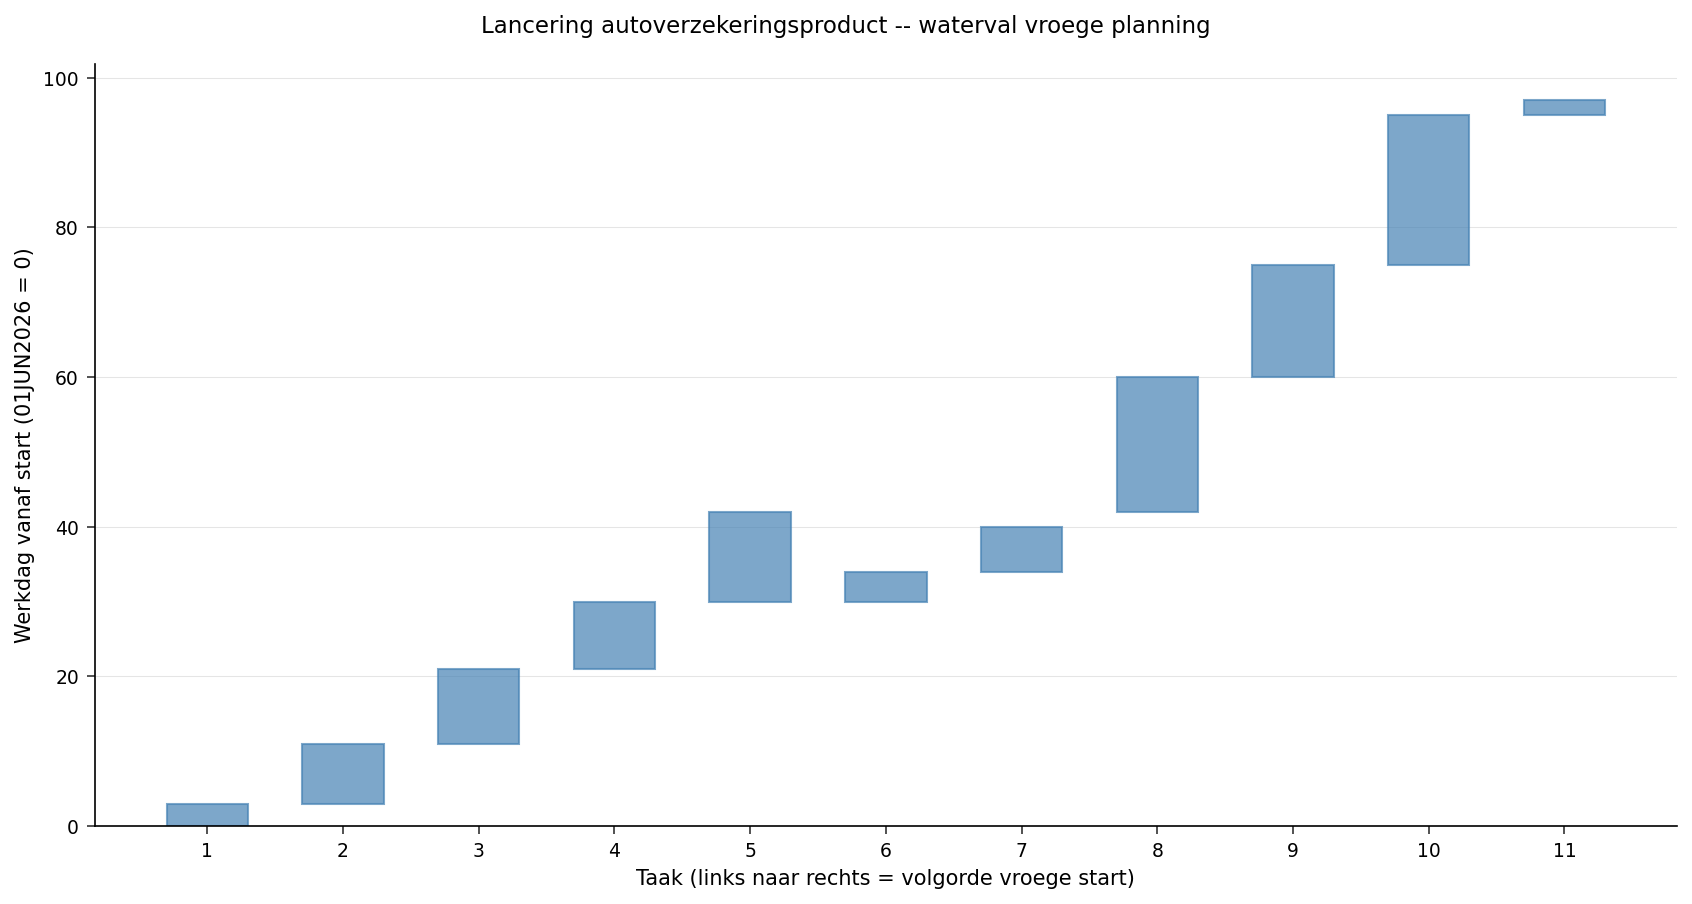

In [8]:
GEGEVENS gantt; INSTELLEN sched_es;
   ord = es;          /* numerieke x = volgorde vroege start */
UITVOEREN;
PROCEDURE SORTEREN GEGEVENS=gantt; VOLGENS ord activity; UITVOEREN;
GEGEVENS gantt; INSTELLEN gantt; ax = _n_; UITVOEREN;   /* compacte x-index 1..11 */

ODS GRAPHICS ON / IMAGENAME='gantt' WIDTH=820px HEIGHT=440px;
TITEL 'Lancering autoverzekeringsproduct -- waterval vroege planning';
PROCEDURE SGPLOT GEGEVENS=gantt;
   highlow x=ax LOW=es HIGH=ef / type=bar barwidth=0.7;
   XAXIS label='Taak (links naar rechts = volgorde vroege start)'
         integer VALUES=(1 TOT 11 VOLGENS 1);
   YAXIS label='Werkdag vanaf start (01JUN2026 = 0)' grid;
UITVOEREN;
ODS GRAPHICS OFF;

Van links naar rechts gelezen stappen de balken continu omhoog langs de kritieke keten. De twee taken waarvan de balken de trap doorbreken -- die lager beginnen dan de bovenkant van de voorgaande balk -- zijn Tariefindiening en Goedkeuring, de activiteiten die speling hebben.

## Totale speling per taak

Het uitzetten van de totale speling per taak maakt het kritieke pad onmiskenbaar: elke kritieke taak staat op nul, en alleen de twee regelgevingstaken komen daarboven uit.

                                   Totale speling per taak (0 = op het kritieke pad)                                    




NOTE: ODS Graphics is ON (width=820px, height=380px, format=SVG).
NOTE: Option TITLE changed to Totale speling per taak (0 = op het kritieke pad).
NOTE: PROC SGPLOT data=sched_es

NOTE: PROC SGPLOT output written to: ./ods_output/float.svg
NOTE: ODS Graphics is OFF.


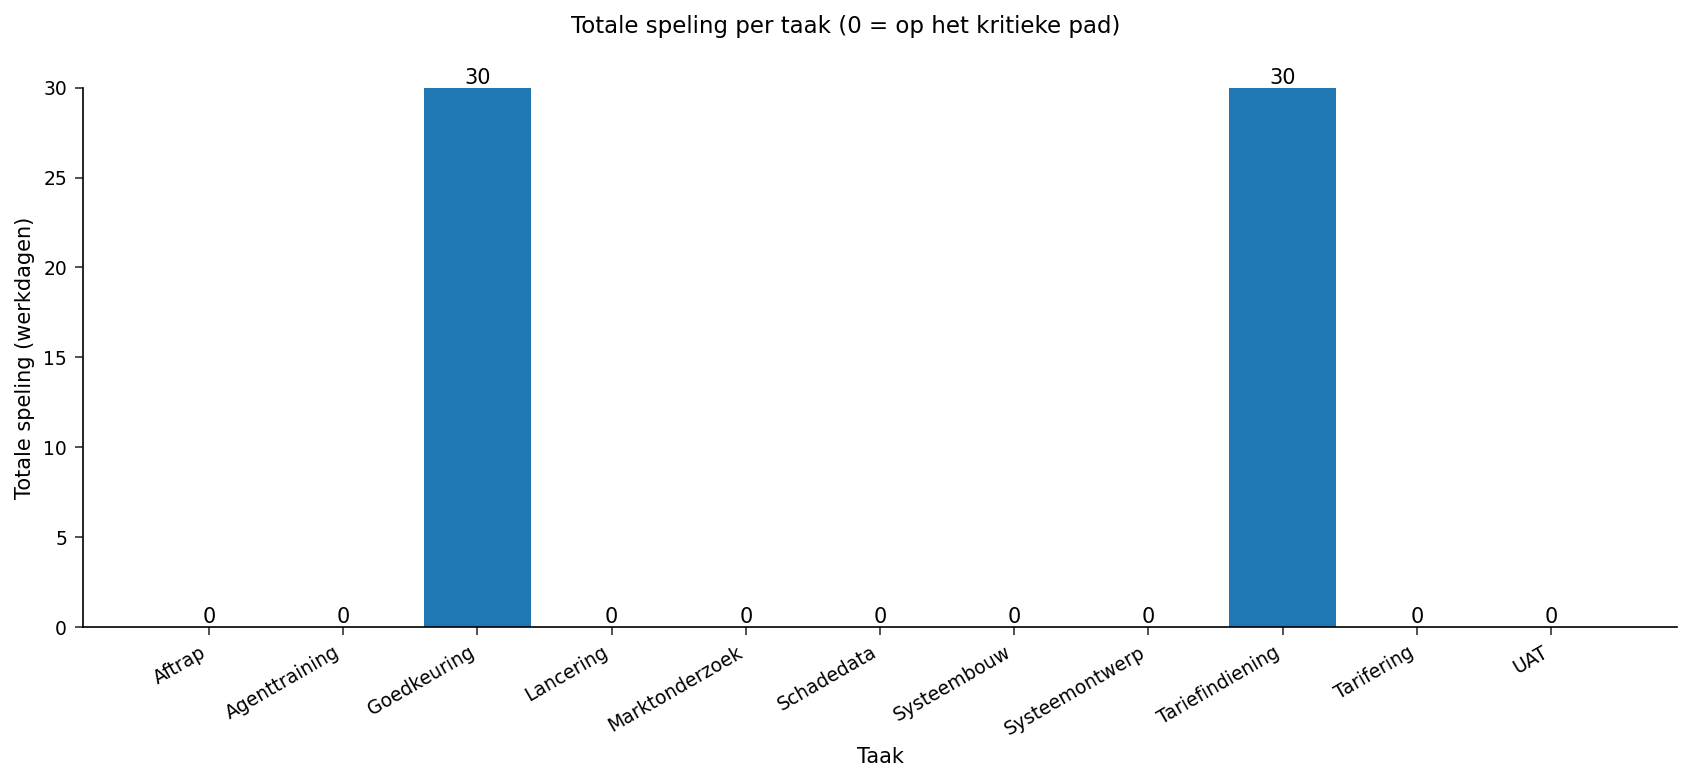

In [9]:
ODS GRAPHICS ON / IMAGENAME='float' WIDTH=820px HEIGHT=380px;
TITEL 'Totale speling per taak (0 = op het kritieke pad)';
PROCEDURE SGPLOT GEGEVENS=sched_es;
   VBAR activity / RESPONSE=tfloat DATALABEL;
   XAXIS label='Taak' fitpolicy=rotatethin;
   YAXIS label='Totale speling (werkdagen)';
UITVOEREN;
ODS GRAPHICS OFF;

## Resourcebelasting onder het vroegste schema

Naast de timing concurreert het plan om twee specialistenpools. Door elke taak uit te spreiden over de werkdagen die ze beslaat en de dagelijkse vraag op te tellen, ontstaat het resourcebelastingsprofiel -- hoeveel actuarissen en ontwikkelaars het plan elke dag nodig heeft als elke taak zo vroeg mogelijk begint. De piek is de meeste capaciteit die het programma ooit tegelijk vereist.

                                   Piekbelasting resources per dag (vroege planning)                                    

                                                  The MEANS Procedure

 Variable    Label             Maximum
 -------------------------------------
 ACTUARIES   Actuarissen             3
 DEVELOPERS  Ontwikkelaars           3
 -------------------------------------

                          Dagelijkse belasting actuaris en ontwikkelaar bij de vroege planning                          




NOTE: DATA load

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 10 rows from sched.
NOTE: Wrote load (105 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: Output dataset rprofile has 90 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=rprofile

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 90 rows from rprofile.
NOTE: Wrote rprofile (90 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Piekbelasting resources per dag (vroege planning).
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: ODS Graphics is ON (width=820px, height=360px, format=SVG).
NOTE: Option TITLE changed to Dagelijkse belasting actuaris en ontwikkelaar bij de vroege planning.
NOTE: PROC SGPLOT data=rprofile

NOTE: PROC SGPLOT output written to: ./ods_output/resload.svg
NOTE: ODS Graphics is OFF.


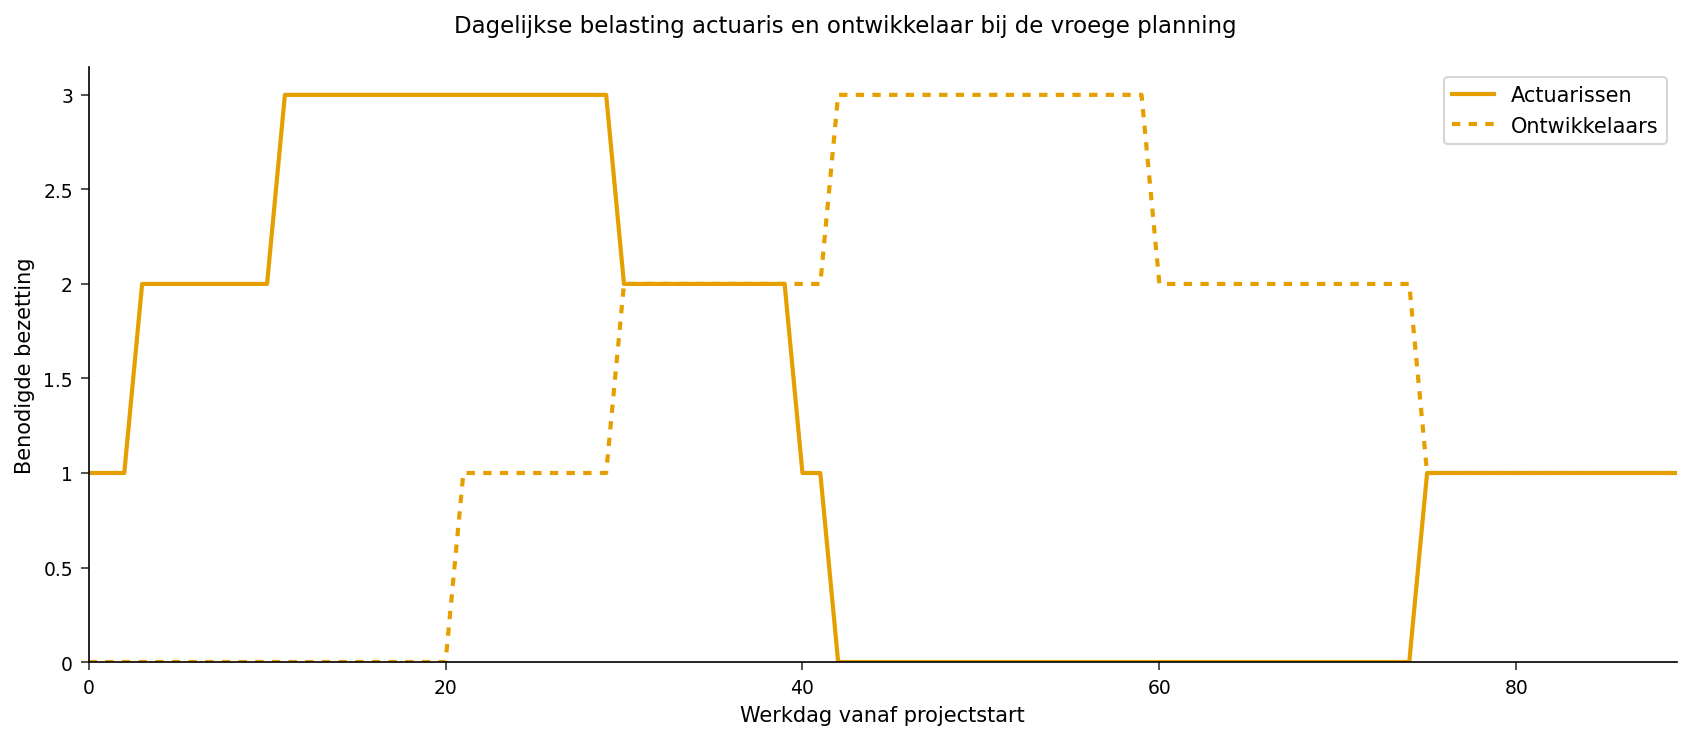

In [10]:
GEGEVENS LOAD;
   INSTELLEN sched;
   DOE d = es TOT ef-1;
      day = d;
      a_use = actuary;
      d_use = developer;
      UITVOER;
   EINDE;
   BEWAREN day a_use d_use;
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=LOAD NOPRINT NWAY;
   KLASSE day;
   VARIABELE a_use d_use;
   UITVOER out=rprofile(VERWIJDEREN=_type_ _freq_)
          sum(a_use)=actuaries sum(d_use)=developers;
UITVOEREN;
PROCEDURE SORTEREN GEGEVENS=rprofile; VOLGENS day; UITVOEREN;

TITEL 'Piekbelasting resources per dag (vroege planning)';
PROCEDURE GEMIDDELDEN GEGEVENS=rprofile MAX maxdec=0;
   VARIABELE actuaries developers;
   label actuaries='Actuarissen' developers='Ontwikkelaars';
UITVOEREN;

ODS GRAPHICS ON / IMAGENAME='resload' WIDTH=820px HEIGHT=360px;
TITEL 'Dagelijkse belasting actuaris en ontwikkelaar bij de vroege planning';
PROCEDURE SGPLOT GEGEVENS=rprofile;
   SERIES x=day y=actuaries  /
          LINEATTRS=(thickness=2) legendlabel='Actuarissen';
   SERIES x=day y=developers /
          LINEATTRS=(thickness=2 pattern=shortdash)
          legendlabel='Ontwikkelaars';
   XAXIS label='Werkdag vanaf projectstart';
   YAXIS label='Benodigde bezetting' MIN=0;
   keylegend / location=inside position=topright;
UITVOEREN;
ODS GRAPHICS OFF;

## De resultaten interpreteren

- **De lanceringsdatum wordt bepaald door het bouwtraject, niet door het regelgevingstraject.** Het kritieke pad loopt Aftrap -> Marktonderzoek -> Schadedata -> Tarifering -> Systeemontwerp -> Systeembouw -> UAT -> Agenttraining -> Lancering, voor een makespan van 97 werkdagen (eindigend op 13OCT2026). Elk van deze taken heeft nul speling, dus elke vertraging erop verschuift de lancering dag voor dag.

- **De regelgevingstak heeft een maand speling.** Tariefindiening en Goedkeuring hebben elk 30 werkdagen totale speling. Nadat tarifering klaar is, kunnen ze zo laat als hun laatste-startdata beginnen en toch op tijd weer aansluiten bij Agenttraining, omdat de parallelle systeembouwtak (Systeemontwerp -> Systeembouw -> UAT) de langere is van de twee paden die naar de lancering leiden. In planningstermen is de indiening hier *niet* de bindende beperking -- de bouw van het polissysteem is dat wel.

- **De vraag naar specialisten piekt in verschillende fasen.** Het belastingsprofiel laat zien dat de vraag naar actuarissen vroeg piekt (tot en met tarifering) en de vraag naar ontwikkelaars later (tot en met de Systeembouw), elk met een maximum van drie personen per dag. Omdat de twee pieken in verschillende fasen vallen, kan een klein, sequentieel specialistenteam het plan bemensen -- het programma heeft niet gelijktijdig zijn maximale bezetting aan actuarissen en ontwikkelaars nodig.

**Zakelijke conclusie.** CPM verandert een lijst lanceringstaken in een uitvoerbaar schema: het identificeert de activiteiten in het bouwtraject die de verzekeraar moet beschermen om 13OCT2026 te halen, kwantificeert de maand speling die beschikbaar is op de wettelijke indiening, en laat zien dat de gespreide pieken van actuarissen en ontwikkelaars een compact specialistenteam in staat stellen het plan te leveren.

*Implementatienotitie:* SAS berekent dit met PROC CPM (SAS/OR). Jenner bereikt hetzelfde voorwaartse/achterwaartse kritieke-padresultaat met PROC OPTMODEL door de twee langste-pad lineaire programma's op te lossen die aan de methode ten grondslag liggen.